# Analyse du Générateur MT19937 (Mersenne Twister)



In [14]:
import sys
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# Ajout du dossier parent pour importer mt19937.py
sys.path.append(os.path.abspath('../generators'))
from mt19937 import mt19937

# Paramètres
N = 50000
SEED = 42

gen_mt = mt19937(seed=SEED)

data_mt = [next(gen_mt) & 0xFF for _ in range(N)]

print(f"Génération terminée : {len(data_mt)} échantillons.")
print(f"Aperçu (10 premiers) : {data_mt[:10]}")

Génération terminée : 50000 échantillons.
Aperçu (10 premiers) : [102, 179, 92, 14, 106, 71, 188, 20, 102, 121]


## 1. Test d'Uniformité (Histogramme)


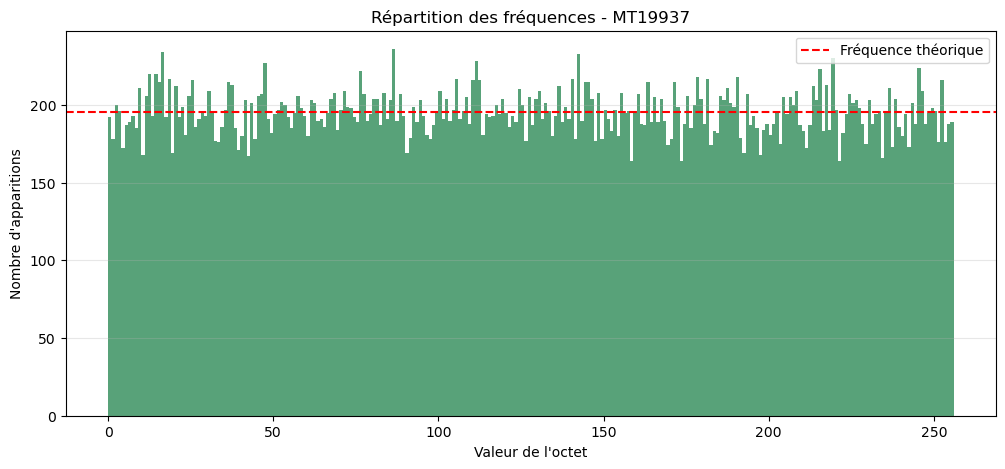

In [15]:
plt.figure(figsize=(12, 5))
plt.hist(data_mt, bins=256, range=(0, 256), color='seagreen', alpha=0.8, edgecolor='none')
plt.axhline(y=N/256, color='red', linestyle='--', label='Fréquence théorique')

plt.title("Répartition des fréquences - MT19937")
plt.xlabel("Valeur de l'octet")
plt.ylabel("Nombre d'apparitions")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. Calcul de l'Entropie de Shannon



In [16]:
def calculate_shannon_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

entropy_mt = calculate_shannon_entropy(data_mt)
print(f"Entropie de Shannon : {entropy_mt:.5f} bits/octet")
print(f"Rapport à l'entropie maximale : {(entropy_mt / 8.0) * 100:.2f}%")

Entropie de Shannon : 7.99634 bits/octet
Rapport à l'entropie maximale : 99.95%


## 3. Test Statistique du $\chi^2$ (Chi-carré)



In [17]:
# Fréquences observées
obs, _ = np.histogram(data_mt, bins=256, range=(0, 256))

# Test du Chi-carré
stat, p_value = chisquare(obs)

print(f"Statistique Chi2 : {stat:.2f}")
print(f"P-value : {p_value:.5f}")

if p_value > 0.05:
    print("Verdict : L'uniformité est statistiquement validée.")
else:
    print("Verdict : Échec de l'uniformité (biais détecté).")

Statistique Chi2 : 254.21
P-value : 0.50213
Verdict : L'uniformité est statistiquement validée.


## 4. Analyse de l'Autocorrélation


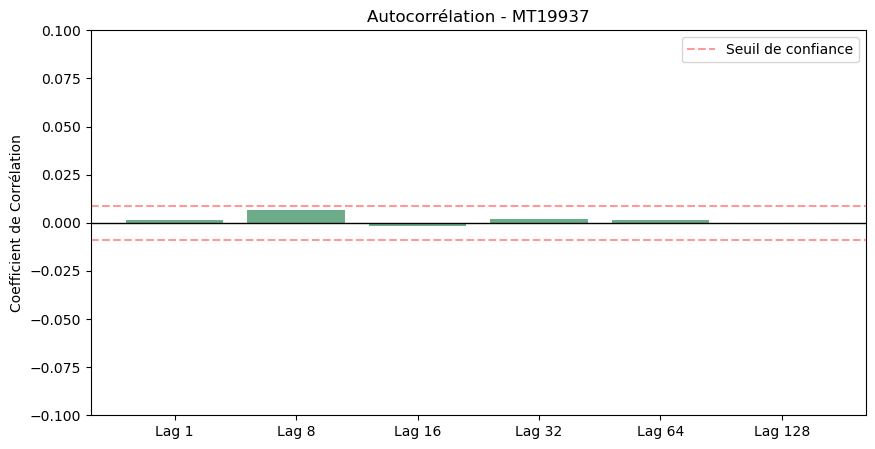

Lag 1 : 0.001406
Lag 8 : 0.006624
Lag 16 : -0.001763
Lag 32 : 0.001973
Lag 64 : 0.001215
Lag 128 : -0.000528


In [18]:
def plot_autocorr_mt(data, lags=[1, 8, 16, 32, 64, 128]):
    corrs = [np.corrcoef(data[:-lag], data[lag:])[0, 1] for lag in lags]
    
    plt.figure(figsize=(10, 5))
    plt.bar([f"Lag {l}" for l in lags], corrs, color='seagreen', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    conf_level = 1.96 / np.sqrt(len(data))
    plt.axhline(y=conf_level, color='red', linestyle='--', alpha=0.4, label='Seuil de confiance')
    plt.axhline(y=-conf_level, color='red', linestyle='--', alpha=0.4)
    
    plt.title("Autocorrélation - MT19937")
    plt.ylabel("Coefficient de Corrélation")
    plt.ylim(-0.1, 0.1)
    plt.legend()
    plt.show()

    for l, c in zip(lags, corrs):
        print(f"Lag {l} : {c:.6f}")

plot_autocorr_mt(data_mt)

## 4. Test de Kolmogorov-Smirnov (KS)


In [19]:
from scipy.stats import kstest

data_norm = np.array(data_mt) / 255.0

statistic_ks, p_value_ks = kstest(data_norm, 'uniform')

print(f"Statistique KS : {statistic_ks:.5f}")
print(f"P-value KS : {p_value_ks:.5f}")

if p_value_ks > 0.05:
    print("\nVerdict : L'uniformité du MT19937 est validée (Succès).")
else:
    print("\nVerdict : Le test détecte un écart à l'uniformité (Échec).")

Statistique KS : 0.00619
P-value KS : 0.04312

Verdict : Le test détecte un écart à l'uniformité (Échec).
